# 👁️ MPIIGaze × L2CS-Net 학습 노트북
## 아이스피크 – ALS 환우분들을 위한 시선 추적 모델

---

### 📌 전체 흐름
```
MPIIGaze.tar.gz (2GB)
  ↓  1. 압축 해제 (최초 1회)
원본 얼굴 사진 (213,658장, 15명)
  ↓  2. mat 파일 + 어노테이션 파일 매핑
3D 시선 벡터 [x, y, z] ← "어디를 바라보는지 나타내는 3D 화살표"
  ↓  3. 수학 공식으로 변환 (arcsin / arctan2)
pitch(위아래 각도°) + yaw(좌우 각도°)
  ↓  4. 얼굴 크롭 (224×224) + ImageNet 정규화
L2CS-Net 입력 준비 완료
  ↓  5. 학습 (MLflow 기록)
ONNX 내보내기 → 브라우저 배포
```

### 💡 왜 MPIIGaze인가?
| 항목 | 기존 데이터셋 (NIA22EYE) | MPIIGaze |
|------|------------------------|---------|
| 이미지 수 | 322장 | 약 45,000장 (Evaluation Subset) |
| 피험자 수 | 소수 | 15명 (다양한 일상 환경) |
| 촬영 환경 | 통제된 환경 | **일상 생활** 중 촬영 |
| 각도 범위 | pitch ±10°, yaw ±4° | **더 넓은 범위** |

## 0. 라이브러리 설치 (처음 한 번만)

In [2]:
# 처음 실행할 때만 주석 해제하고 실행하세요
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install scipy mlflow scikit-learn tqdm matplotlib numpy pillow

Looking in indexes: https://download.pytorch.org/whl/cu121


## 1. 라이브러리 불러오기

In [3]:
import os
import io
import math
import tarfile
import pickle
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import mlflow
import mlflow.pytorch

print(f"PyTorch 버전: {torch.__version__}")
print(f"GPU 사용 가능: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"학습 장치: {device}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")

PyTorch 버전: 2.5.1+cu121
GPU 사용 가능: True
학습 장치: cuda
GPU 이름: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. ⚙️ 설정 (여기서 값을 바꿔서 실험하세요!)

In [4]:
# ────────────────────────────────────────────────────────────────
#  📂 경로 설정
# ────────────────────────────────────────────────────────────────
BASE_DIR    = Path(".")
TAR_PATH    = BASE_DIR / ".." / "MPIIGaze.tar.gz"
EXTRACT_DIR = BASE_DIR / ".." / "MPIIGaze"
INDEX_CSV   = BASE_DIR / "mpiigaze_index.csv"

runs_dir = BASE_DIR / "checkpoints"
runs_dir.mkdir(exist_ok=True)
existing = [d for d in runs_dir.iterdir() if d.is_dir() and d.name.startswith("run_")]
run_num  = len(existing) + 1
RUN_NAME = f"run_{run_num:03d}_{datetime.now().strftime('%Y%m%d_%H%M')}_mpii_ep{40}"
SAVE_DIR = runs_dir / RUN_NAME
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ────────────────────────────────────────────────────────────────
#  🏋️ 학습 하이퍼파라미터 ← 여기서 값을 바꿔보세요!
# ────────────────────────────────────────────────────────────────
NUM_BINS      = 28
ANGLE_MIN     = -15.0
ANGLE_MAX     =  15.0

BATCH_SIZE    = 32       # ← 여기서 값을 바꿔보세요! (클수록 GPU 활용률 ↑, 속도 ↑)
NUM_EPOCHS    = 10       # ← 여기서 값을 바꿔보세요! (테스트: 10 / 정식: 40)
LR_BACKBONE   = 1e-5     # ← 여기서 값을 바꿔보세요!
LR_HEAD       = 1e-4     # ← 여기서 값을 바꿔보세요!
WEIGHT_DECAY  = 1e-4     # ← 여기서 값을 바꿔보세요!
ALPHA         = 1.0      # ← 여기서 값을 바꿔보세요!
TRAIN_RATIO   = 0.8
RANDOM_SEED   = 42

BIN_SIZE    = (ANGLE_MAX - ANGLE_MIN) / NUM_BINS
BIN_CENTERS = np.array([ANGLE_MIN + BIN_SIZE * (i + 0.5) for i in range(NUM_BINS)],
                        dtype=np.float32)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print(f"이번 실행 이름: {RUN_NAME}")
print(f"저장 폴더: {SAVE_DIR}")
print(f"각도 범위: {ANGLE_MIN}° ~ {ANGLE_MAX}°  (구간 크기: {BIN_SIZE:.3f}°)")


이번 실행 이름: run_004_20260306_0708_mpii_ep40
저장 폴더: checkpoints\run_004_20260306_0708_mpii_ep40
각도 범위: -15.0° ~ 15.0°  (구간 크기: 1.071°)


## 3. 📦 MPIIGaze 압축 해제 (최초 1회만)

2GB 파일이라 **처음 한 번만** 실행하면 됩니다.  
이미 해제되어 있으면 이 셀은 건너뜁니다.

In [5]:
def extract_mpiigaze(tar_path, extract_dir):
    """
    MPIIGaze.tar.gz를 풀어서 폴더로 저장합니다.
    이미 풀려 있으면 건너뜁니다.
    """
    # 이미 해제된 경우 건너뜀
    if extract_dir.exists() and (extract_dir / "MPIIGaze").exists():
        print(f"이미 압축 해제되어 있습니다: {extract_dir / 'MPIIGaze'}")
        return

    extract_dir.mkdir(parents=True, exist_ok=True)
    print(f"압축 해제 시작... (약 5~10분 소요될 수 있습니다)")
    print(f"저장 위치: {extract_dir}")

    with tarfile.open(str(tar_path), 'r:gz') as t:
        members = t.getmembers()
        # tqdm으로 진행률 표시
        for member in tqdm(members, desc="압축 해제 중"):
            t.extract(member, path=str(extract_dir))

    print("압축 해제 완료!")


extract_mpiigaze(TAR_PATH.resolve(), EXTRACT_DIR.resolve())

# 경로 확인
MPII_ROOT  = EXTRACT_DIR / "MPIIGaze"            # MPIIGaze 루트
ORIG_DIR   = MPII_ROOT / "Data" / "Original"     # 원본 얼굴 사진
NORM_DIR   = MPII_ROOT / "Data" / "Normalized"   # mat 파일 (3D gaze 포함)
EVAL_DIR   = MPII_ROOT / "Evaluation Subset"     # 어노테이션 파일
ANN_DIR    = EVAL_DIR / "annotation for face image"
SAMPLE_DIR = EVAL_DIR / "sample list for eye image"

print(f"\n원본 얼굴 사진 폴더 존재: {ORIG_DIR.exists()}")
print(f"Normalized mat 폴더 존재: {NORM_DIR.exists()}")
print(f"어노테이션 폴더 존재:     {ANN_DIR.exists()}")

이미 압축 해제되어 있습니다: C:\Users\SSAFY\Desktop\AI\eye_tracking\MPIIGaze\MPIIGaze

원본 얼굴 사진 폴더 존재: True
Normalized mat 폴더 존재: True
어노테이션 폴더 존재:     True


## 4. 🧮 핵심 함수: 3D 시선 벡터 → pitch/yaw 변환

### 비유로 이해하기

> 당신이 지금 어딘가를 바라보고 있다고 상상해보세요.  
> 그 시선을 3D 화살표(벡터)로 표현하면 → `[x, y, z]`  
> - `x` = 화살표가 왼쪽/오른쪽으로 기울어진 정도  
> - `y` = 화살표가 위/아래로 기울어진 정도  
> - `z` = 화살표가 앞뒤로 향하는 정도 (화면을 바라봄 = z가 음수)
>  
> **pitch** = 화살표가 수평면 기준으로 얼마나 위아래로 기울었는지 (각도)  
> **yaw**   = 화살표가 정면 기준으로 얼마나 좌우로 돌아갔는지 (각도)  
>  
> 마치 나침반 바늘(yaw)과 시소(pitch)처럼 생각하면 쉬워요!

In [6]:
def gaze_vec_to_angles(gaze_vec):
    """
    3D 시선 벡터 [x, y, z]를 pitch(위아래 각도)와 yaw(좌우 각도)로 변환합니다.
    결과는 도(°) 단위입니다.

    📐 공식 설명 (초등학생도 이해할 수 있게!)
    ─────────────────────────────────────────────────────────────
    [좌표계 약속]
      x: 오른쪽이 양수(+), 왼쪽이 음수(-)
      y: 아래쪽이 양수(+), 위쪽이 음수(-) ← 카메라 좌표계 기준
      z: 화면 쪽(앞)이 음수(-), 뒤쪽이 양수(+)

    [pitch 계산: arcsin(-y)]
      예) y = 0.26 (살짝 아래쪽)  → pitch = arcsin(-0.26) ≈ -15°
          → 화살표가 아래쪽을 향하면 pitch가 음수 (아래를 봄)
      비유: 시소에서 내 쪽이 올라가면 + (위를 봄), 내려가면 - (아래를 봄)

    [yaw 계산: arctan2(-x, -z)]
      예) x = -0.13, z = -0.96  → yaw = arctan2(0.13, 0.96) ≈ +7.7°
          → 화살표가 왼쪽을 향하면 yaw가 양수 (왼쪽을 봄)
      비유: 나침반처럼, 정면이 0°, 왼쪽으로 돌면 + (왼쪽을 봄)
    ─────────────────────────────────────────────────────────────
    """
    # 단위벡터 정규화 (혹시라도 길이가 1이 아닌 경우 대비)
    # 비유: 화살표 길이를 항상 "1"로 맞추는 작업
    gaze_vec = np.array(gaze_vec, dtype=np.float64)
    norm = np.linalg.norm(gaze_vec)
    if norm > 1e-6:
        gaze_vec = gaze_vec / norm

    x, y, z = gaze_vec

    # ── pitch (위아래 각도) ────────────────────────────────────
    # arcsin = "사인 값으로 각도를 역산하는 함수"
    # y가 음수(위를 봄) → pitch가 양수
    # y가 양수(아래를 봄) → pitch가 음수
    # np.clip: -1~1 범위를 벗어나면 오류가 날 수 있어서 안전하게 자름
    pitch_rad = np.arcsin(-np.clip(y, -1.0, 1.0))

    # ── yaw (좌우 각도) ──────────────────────────────────────
    # arctan2 = "x/z 비율로 각도를 역산하는 함수"
    # -x, -z로 부호를 바꾸는 이유:
    #   카메라가 정면을 보는 방향(z-)을 기준으로 각도를 재기 위해서
    yaw_rad = np.arctan2(-x, -z)

    # 라디안(0~2π) → 도(-180~180)로 변환
    # 비유: 지도에서 "방위각 1.57라디안"보다 "북쪽에서 90도"가 더 이해하기 쉽죠?
    pitch_deg = float(np.degrees(pitch_rad))
    yaw_deg   = float(np.degrees(yaw_rad))

    return pitch_deg, yaw_deg


def angle_to_bin(angle_deg, angle_min, bin_size, num_bins):
    """
    각도(도 단위)를 몇 번 구간(Bin)에 해당하는지 숫자로 바꿉니다.

    비유: -15°~+15° 범위를 28칸으로 나눈 자(ruler)에서
          "지금 각도가 몇 번 칸에 들어가는지" 찾는 것입니다.
    """
    bin_idx = int((angle_deg - angle_min) / bin_size)
    # 범위를 벗어나면 가장자리 Bin으로 고정 (안전 처리)
    return max(0, min(num_bins - 1, bin_idx))


# ── 동작 확인 ───────────────────────────────────────────────────
test_gaze = np.array([-0.116, 0.089, -0.989])  # 예시 gaze 벡터
pitch, yaw = gaze_vec_to_angles(test_gaze)
p_bin = angle_to_bin(pitch, ANGLE_MIN, BIN_SIZE, NUM_BINS)
y_bin = angle_to_bin(yaw,   ANGLE_MIN, BIN_SIZE, NUM_BINS)

print("=" * 55)
print(f"입력 gaze 벡터:  x={test_gaze[0]:.3f}  y={test_gaze[1]:.3f}  z={test_gaze[2]:.3f}")
print(f"  → pitch:  {pitch:+.2f}°  (구간 {p_bin}번 / {NUM_BINS})")
print(f"  → yaw  :  {yaw:+.2f}°  (구간 {y_bin}번 / {NUM_BINS})")
print("=" * 55)
print("해석: 모니터 앞에서 살짝 아래를 내려다보고 약간 왼쪽을 보는 상태")

입력 gaze 벡터:  x=-0.116  y=0.089  z=-0.989
  → pitch:  -5.11°  (구간 9번 / 28)
  → yaw  :  +6.69°  (구간 20번 / 28)
해석: 모니터 앞에서 살짝 아래를 내려다보고 약간 왼쪽을 보는 상태


## 5. 📋 샘플 인덱스 CSV 만들기

모든 샘플의 정보(이미지 경로, pitch, yaw, 얼굴 랜드마크)를  
하나의 CSV 파일로 정리합니다. 학습 때마다 빠르게 불러올 수 있어요!

In [7]:
def build_gaze_lookup(norm_dir, subjects):
    """
    Normalized mat 파일들을 읽어서
    '피험자/day/파일명' → (left_gaze, right_gaze) 를 빠르게 찾을 수 있는
    사전(dictionary)을 만듭니다.

    비유: "p00이 day01에서 0005.jpg를 찍을 때 어디를 봤는지"
          빠르게 찾아볼 수 있는 인덱스 카드를 만드는 것입니다.
    """
    lookup = {}   # { 'p00/day01/0005.jpg': (left_gaze_vec, right_gaze_vec) }

    for subj in tqdm(subjects, desc="gaze 사전 구축 중"):
        subj_dir = norm_dir / subj
        if not subj_dir.exists():
            continue

        # 해당 피험자의 모든 dayXX.mat 파일 순회
        for mat_path in sorted(subj_dir.glob("*.mat")):
            day = mat_path.stem   # 예: "day01"

            mat = sio.loadmat(str(mat_path))
            filenames = [mat['filenames'][i][0][0] for i in range(len(mat['filenames']))]

            # 왼쪽 눈 / 오른쪽 눈 gaze 벡터
            left_gazes  = mat['data'][0][0]['left'][0][0]['gaze']   # (N, 3)
            right_gazes = mat['data'][0][0]['right'][0][0]['gaze']  # (N, 3)

            for i, fname in enumerate(filenames):
                # 키 형식: 'p00/day01/0005.jpg'
                key = f"{subj}/{day}/{fname}"
                lookup[key] = (
                    left_gazes[i].tolist(),
                    right_gazes[i].tolist()
                )

    return lookup


def parse_annotation(ann_path):
    """
    어노테이션 파일을 읽어서 파일명 → 6개 얼굴 랜드마크 좌표 사전을 만듭니다.

    어노테이션 형식:
      day01/0005.jpg  x1 y1 x2 y2 x3 y3 x4 y4 x5 y5 x6 y6
      → 6개 얼굴 특징점 (눈 4개 + 입꼬리 2개)
    """
    annotations = {}   # { 'day01/0005.jpg': [[x1,y1], [x2,y2], ...] }

    with open(ann_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 13:
                continue
            img_rel = parts[0]                      # 예: 'day01/0005.jpg'
            coords  = list(map(float, parts[1:]))   # 12개 숫자
            # 12개 숫자를 6개 (x, y) 쌍으로 묶기
            landmarks = [[coords[j*2], coords[j*2+1]] for j in range(6)]
            annotations[img_rel] = landmarks

    return annotations


def compute_crop_params(landmarks):
    """
    6개 얼굴 랜드마크로 얼굴 크롭 영역을 계산합니다.
    L2CS-Net 학습 코드와 완전히 동일한 방식!

    랜드마크 구성:
      0,1 → 왼쪽 눈 (안쪽/바깥쪽 코너)
      2,3 → 오른쪽 눈 (안쪽/바깥쪽 코너)
      4,5 → 입꼬리 (왼쪽/오른쪽)

    크롭 공식:
      눈 사이 거리(IED) = 왼쪽 눈 중심 ~ 오른쪽 눈 중심
      크롭 크기         = IED × 3.5
      크롭 중심 Y       = 눈 중심 Y + IED × 0.25 (코/턱 포함을 위해 아래로 조정)
    """
    lm = np.array(landmarks)  # (6, 2)

    # 왼쪽/오른쪽 눈 중심 계산 (두 코너의 평균)
    left_eye_center  = (lm[0] + lm[1]) / 2   # [x, y]
    right_eye_center = (lm[2] + lm[3]) / 2   # [x, y]

    # 눈 사이 거리 (IED)
    ied = np.linalg.norm(right_eye_center - left_eye_center)
    if ied < 10:   # 너무 작으면 감지 실패로 간주
        return None

    # 얼굴 크롭 중심과 크기
    center_x = (left_eye_center[0] + right_eye_center[0]) / 2
    center_y = (left_eye_center[1] + right_eye_center[1]) / 2 + ied * 0.25
    crop_size = int(ied * 3.5)

    # 크롭 박스 좌표 (left, top, right, bottom)
    half = crop_size // 2
    x1, y1 = int(center_x - half), int(center_y - half)
    x2, y2 = x1 + crop_size, y1 + crop_size

    return (x1, y1, x2, y2, crop_size)


def build_index(subjects, orig_dir, norm_dir, ann_dir, sample_dir,
                index_csv, angle_min, bin_size, num_bins):
    """
    모든 피험자 데이터를 하나의 DataFrame으로 정리하고 CSV로 저장합니다.
    """
    if index_csv.exists():
        print(f"기존 인덱스 발견! 불러옵니다: {index_csv}")
        df = pd.read_csv(index_csv)
        print(f"총 {len(df)}개 샘플 로드 완료")
        return df

    print("인덱스 생성 중 (최초 1회, 약 5~10분 소요)...")

    # Step 1: gaze 벡터 사전 구축
    gaze_lookup = build_gaze_lookup(norm_dir, subjects)
    print(f"gaze 사전 완성: {len(gaze_lookup)}개 항목")

    records = []  # 최종 DataFrame 행들을 모을 리스트

    for subj in tqdm(subjects, desc="어노테이션 처리 중"):
        ann_path    = ann_dir    / f"{subj}.txt"
        sample_path = sample_dir / f"{subj}.txt"

        if not ann_path.exists() or not sample_path.exists():
            continue

        # 어노테이션 읽기: { 'day01/0005.jpg': [[x1,y1], ...] }
        annotations = parse_annotation(ann_path)

        # 샘플 목록 읽기: 어떤 이미지를, 어느 눈 기준으로 쓸지
        with open(sample_path, 'r', encoding='utf-8') as f:
            sample_lines = [l.strip() for l in f if l.strip()]

        for line in sample_lines:
            parts = line.split()
            if len(parts) < 2:
                continue

            img_rel   = parts[0]                 # 예: 'day01/0514.jpg'
            eye_side  = parts[1].lower()         # 'left' 또는 'right'
            day_fname = img_rel                  # 예: 'day01/0514.jpg'
            fname     = Path(img_rel).name       # 예: '0514.jpg'
            day       = Path(img_rel).parent.name  # 예: 'day01'

            # gaze 벡터 조회 (피험자/day/파일명 키로 찾기)
            lookup_key = f"{subj}/{day}/{fname}"
            if lookup_key not in gaze_lookup:
                continue

            left_gaze, right_gaze = gaze_lookup[lookup_key]

            # 사용할 눈에 따라 gaze 벡터 선택
            # ReadMe에 따르면 오른쪽 눈 샘플은 얼굴 이미지를 좌우 반전
            # → gaze의 x 방향도 반전해야 함
            if eye_side == 'right':
                gaze_vec = right_gaze.copy()
                gaze_vec[0] = -gaze_vec[0]   # x 반전 (좌우 뒤집기)
                flip_image = True
            else:
                gaze_vec = left_gaze
                flip_image = False

            # 3D 벡터 → pitch/yaw 변환
            pitch_deg, yaw_deg = gaze_vec_to_angles(gaze_vec)

            # 어노테이션(랜드마크)이 있어야 얼굴 크롭 가능
            if img_rel not in annotations:
                continue
            landmarks = annotations[img_rel]

            # 얼굴 크롭 파라미터 계산
            crop = compute_crop_params(landmarks)
            if crop is None:
                continue
            x1, y1, x2, y2, crop_size = crop

            # 원본 이미지 경로 (상대 경로로 저장)
            img_full_path = orig_dir / subj / img_rel
            if not img_full_path.exists():
                continue

            # 구간(Bin) 번호 계산
            pitch_bin = angle_to_bin(pitch_deg, angle_min, bin_size, num_bins)
            yaw_bin   = angle_to_bin(yaw_deg,   angle_min, bin_size, num_bins)

            records.append({
                'img_path':   str(img_full_path),
                'subject':    subj,
                'eye_side':   eye_side,
                'flip':       flip_image,
                'pitch_deg':  round(pitch_deg, 4),
                'yaw_deg':    round(yaw_deg,   4),
                'pitch_bin':  pitch_bin,
                'yaw_bin':    yaw_bin,
                # 크롭 좌표 저장
                'crop_x1':    x1, 'crop_y1': y1,
                'crop_x2':    x2, 'crop_y2': y2,
            })

    df = pd.DataFrame(records)
    df.to_csv(str(index_csv), index=False)
    print(f"\n인덱스 저장 완료: {index_csv}")
    print(f"총 샘플 수: {len(df)}")
    return df


# 피험자 목록 (p00 ~ p14)
SUBJECTS = [f"p{i:02d}" for i in range(15)]

# 인덱스 CSV 생성 (또는 불러오기)
df_all = build_index(
    subjects  = SUBJECTS,
    orig_dir  = ORIG_DIR,
    norm_dir  = NORM_DIR,
    ann_dir   = ANN_DIR,
    sample_dir= SAMPLE_DIR,
    index_csv = INDEX_CSV,
    angle_min = ANGLE_MIN,
    bin_size  = BIN_SIZE,
    num_bins  = NUM_BINS
)

print(f"\n📊 인덱스 미리보기:")
print(df_all[['subject','eye_side','pitch_deg','yaw_deg','pitch_bin','yaw_bin']].head(5).to_string(index=False))

기존 인덱스 발견! 불러옵니다: mpiigaze_index.csv
총 44998개 샘플 로드 완료

📊 인덱스 미리보기:
subject eye_side  pitch_deg  yaw_deg  pitch_bin  yaw_bin
    p00     left    -2.9862  14.1727         11       27
    p00     left   -13.1748   4.3700          1       18
    p00     left    -1.7460  10.0303         12       23
    p00     left   -10.2463   1.4543          4       15
    p00     left    -3.3204   9.3051         10       22


## 6. 📊 데이터 탐색: 각도 분포 확인

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\947253079.py:27: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\947253079.py:27: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\947253079.py:27: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\947253079.py:27: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\947253079.py:27: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\947253079.py:27: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from fo

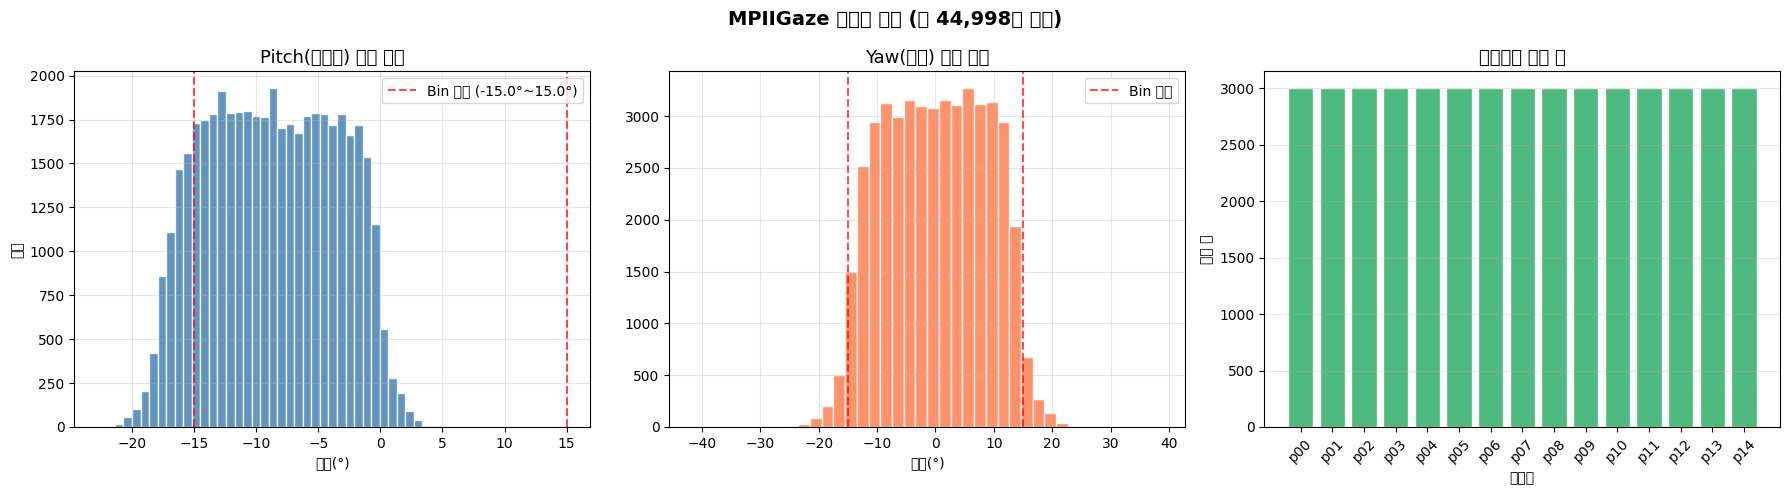


Pitch: min=-22.8°  max=4.8°
Yaw  : min=-41.5°   max=38.7°

Bin 범위(-15.0°~15.0°) 벗어난 샘플: 7972개 → 가장자리 Bin으로 처리


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pitch 분포
axes[0].hist(df_all['pitch_deg'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(ANGLE_MIN, color='red', linestyle='--', alpha=0.7, label=f'Bin 범위 ({ANGLE_MIN}°~{ANGLE_MAX}°)')
axes[0].axvline(ANGLE_MAX, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('Pitch(위아래) 각도 분포', fontsize=13)
axes[0].set_xlabel('각도(°)'); axes[0].set_ylabel('빈도')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Yaw 분포
axes[1].hist(df_all['yaw_deg'], bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(ANGLE_MIN, color='red', linestyle='--', alpha=0.7, label=f'Bin 범위')
axes[1].axvline(ANGLE_MAX, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Yaw(좌우) 각도 분포', fontsize=13)
axes[1].set_xlabel('각도(°)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# 피험자별 샘플 수
subj_counts = df_all['subject'].value_counts().sort_index()
axes[2].bar(subj_counts.index, subj_counts.values, color='mediumseagreen', edgecolor='white', alpha=0.9)
axes[2].set_title('피험자별 샘플 수', fontsize=13)
axes[2].set_xlabel('피험자'); axes[2].set_ylabel('샘플 수')
axes[2].tick_params(axis='x', rotation=45); axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'MPIIGaze 데이터 분포 (총 {len(df_all):,}개 샘플)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'mpiigaze_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n{'='*50}")
print(f"Pitch: min={df_all['pitch_deg'].min():.1f}°  max={df_all['pitch_deg'].max():.1f}°")
print(f"Yaw  : min={df_all['yaw_deg'].min():.1f}°   max={df_all['yaw_deg'].max():.1f}°")
out_of_range = ((df_all['pitch_deg'] < ANGLE_MIN) | (df_all['pitch_deg'] > ANGLE_MAX) |
                (df_all['yaw_deg']   < ANGLE_MIN) | (df_all['yaw_deg']   > ANGLE_MAX))
print(f"\nBin 범위({ANGLE_MIN}°~{ANGLE_MAX}°) 벗어난 샘플: {out_of_range.sum()}개 → 가장자리 Bin으로 처리")
print(f"{'='*50}")

## 7. 📦 PyTorch 데이터셋 클래스

In [9]:
# ImageNet 정규화 통계 (ResNet이 학습된 방식과 동일하게)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# 학습용 전처리 (데이터 증강 포함)
# 비유: 같은 사진을 밝기 바꾸고 살짝 기울여서 "다른 환경에서 찍은 것처럼" 만들어요
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),                              # ResNet 입력 크기
    transforms.ColorJitter(brightness=0.3, contrast=0.3,       # 밝기·대비 랜덤 변경
                           saturation=0.3, hue=0.0),
    transforms.RandomGrayscale(p=0.1),                         # 10% 확률로 흑백 변환
    transforms.RandomAffine(degrees=8, translate=(0.05, 0.05), # 살짝 회전·이동
                            scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# 검증용 전처리 (증강 없음, 크기만 맞춤)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class MPIIGazeDataset(Dataset):
    """
    MPIIGaze 얼굴 사진을 불러와서 L2CS-Net에 먹이기 좋은 형태로
    준비해주는 데이터셋 클래스입니다.

    반환 형식:
      image      : [3, 224, 224] 텐서  ← ResNet 입력
      pitch_bin  : int (0~27)          ← 분류 손실용
      yaw_bin    : int (0~27)          ← 분류 손실용
      pitch_cont : float (도 단위)     ← 회귀 손실용
      yaw_cont   : float (도 단위)     ← 회귀 손실용
    """

    def __init__(self, dataframe, transform=None):
        """
        dataframe : build_index()가 만든 판다스 DataFrame
        transform : 이미지 전처리 (학습용/검증용 구분)
        """
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        # 전체 샘플 수 반환
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── 1. 이미지 불러오기 ───────────────────────────────
        try:
            img = Image.open(row['img_path']).convert('RGB')
        except Exception:
            # 이미지를 못 불러오면 빈 이미지로 대체 (학습 중단 방지)
            img = Image.new('RGB', (224, 224), color=(128, 128, 128))

        # ── 2. 얼굴 크롭 ────────────────────────────────────
        x1, y1, x2, y2 = int(row['crop_x1']), int(row['crop_y1']), \
                          int(row['crop_x2']), int(row['crop_y2'])

        W, H = img.size
        # 이미지 경계를 벗어나지 않도록 조정
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)

        if x2 > x1 and y2 > y1:
            img = img.crop((x1, y1, x2, y2))

        # ── 3. 오른쪽 눈 샘플은 좌우 반전 ────────────────────
        # ReadMe: 오른쪽 눈 → 왼쪽 눈처럼 보이도록 이미지를 거울 반전
        if row['flip']:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)

        # ── 4. 전처리 (크기 조정 + 정규화) ─────────────────
        if self.transform:
            img = self.transform(img)

        # ── 5. 라벨 반환 ──────────────────────────────────
        return (
            img,                                                    # [3, 224, 224]
            torch.tensor(int(row['pitch_bin']), dtype=torch.long), # 구간 번호 (정수)
            torch.tensor(int(row['yaw_bin']),   dtype=torch.long), # 구간 번호 (정수)
            torch.tensor(float(row['pitch_deg']), dtype=torch.float32),  # 연속 각도
            torch.tensor(float(row['yaw_deg']),   dtype=torch.float32),  # 연속 각도
        )


# 동작 확인
test_ds = MPIIGazeDataset(df_all.head(5), transform=val_transform)
img, p_bin, y_bin, p_cont, y_cont = test_ds[0]
print(f"이미지 텐서 크기 : {img.shape}")
print(f"pitch → bin={p_bin.item()}번  값={p_cont.item():.2f}°")
print(f"yaw   → bin={y_bin.item()}번  값={y_cont.item():.2f}°")

이미지 텐서 크기 : torch.Size([3, 224, 224])
pitch → bin=11번  값=-2.99°
yaw   → bin=27번  값=14.17°


## 8. 🔄 학습/검증 데이터 분할 (8:2) + DataLoader 생성

In [10]:
# 8:2로 나누기 (피험자 단위로 섞어서 고르게 분포)
train_df, val_df = train_test_split(
    df_all,
    train_size=TRAIN_RATIO,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=df_all['subject']   # 피험자 비율 유지 (특정 사람만 학습/검증 안 되게)
)

# 데이터셋 생성
train_dataset = MPIIGazeDataset(train_df, transform=train_transform)  # 증강 O
val_dataset   = MPIIGazeDataset(val_df,   transform=val_transform)    # 증강 X

# DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,             # ✅ Windows에서는 반드시 0! (4 이상이면 오히려 느려짐)
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,             # ✅ Windows에서는 반드시 0!
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

print(f"학습 데이터 : {len(train_dataset):,}장  →  {len(train_loader)}배치")
print(f"검증 데이터 : {len(val_dataset):,}장   →  {len(val_loader)}배치")
print(f"배치 크기   : {BATCH_SIZE}")


학습 데이터 : 35,998장  →  1124배치
검증 데이터 : 9,000장   →  282배치
배치 크기   : 32


## 9. 🔬 샘플 이미지 시각화

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\3177740996.py:18: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\3177740996.py:18: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\3177740996.py:18: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\3177740996.py:18: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\3177740996.py:18: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\3177740996.py:18: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missin

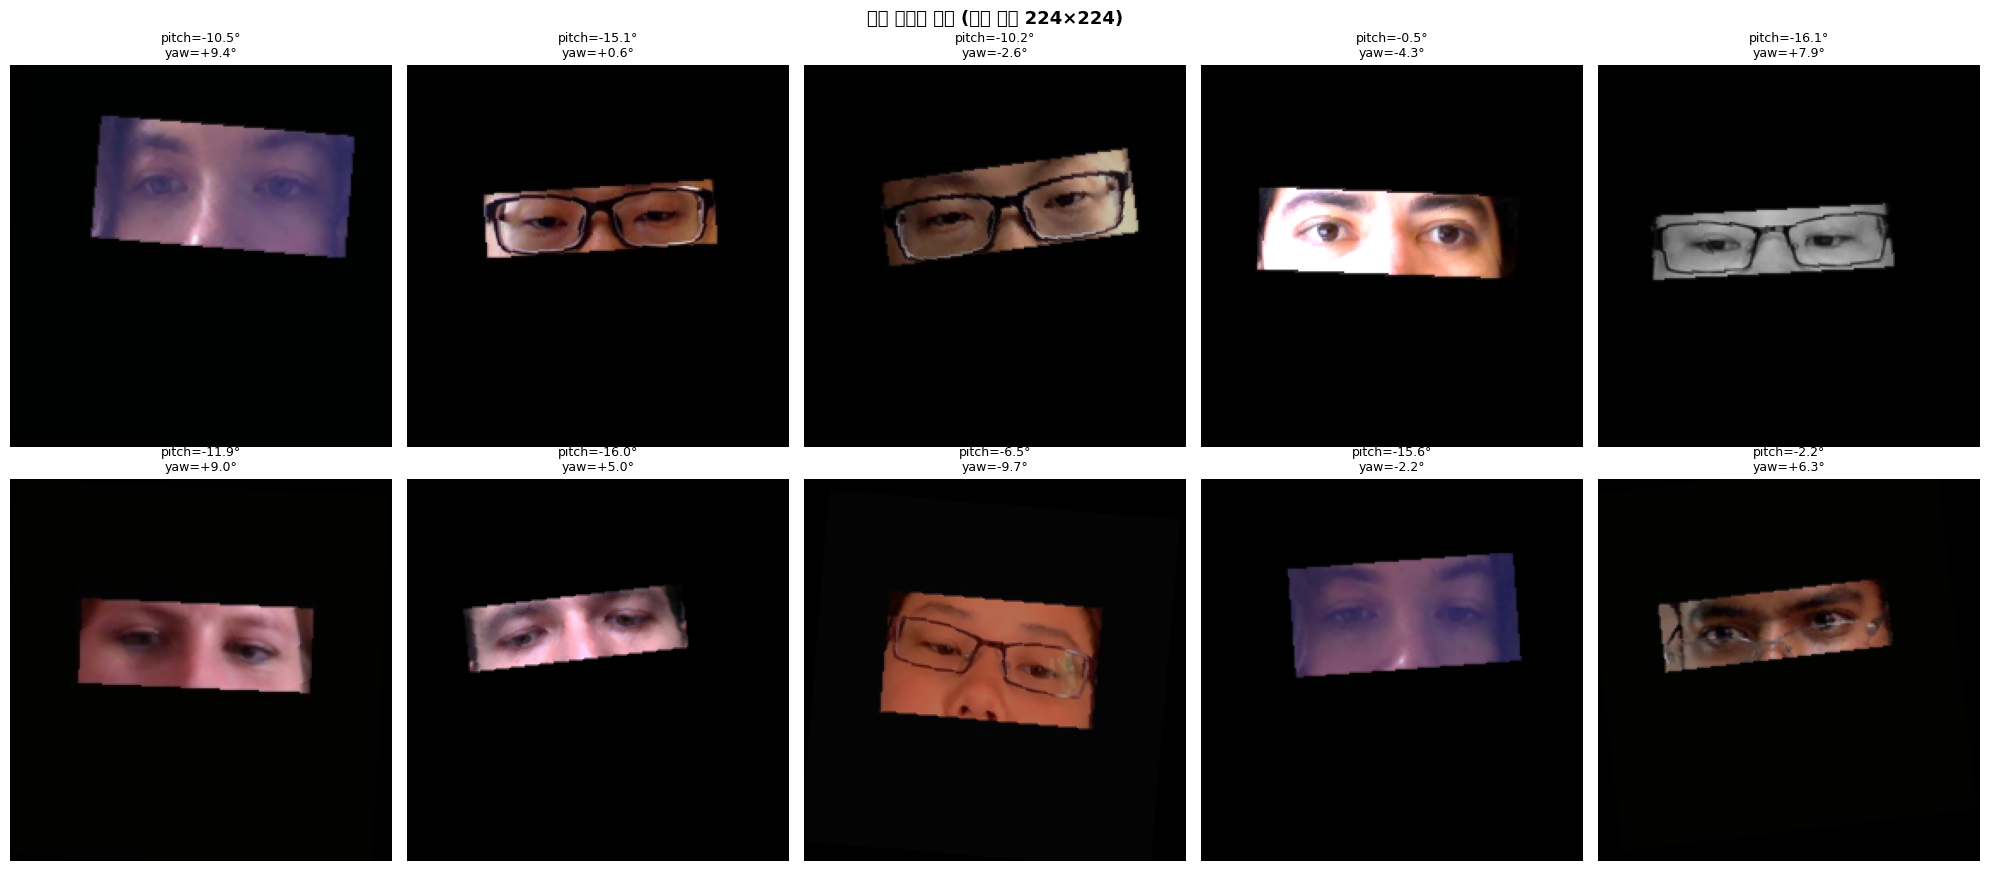

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
sample_indices = np.linspace(0, len(train_dataset)-1, 10, dtype=int)

# ImageNet 역정규화 (시각화를 위해)
inv_mean = torch.tensor([-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)])
inv_std  = torch.tensor([1/s for s in IMAGENET_STD])
inv_norm = transforms.Normalize(mean=inv_mean.tolist(), std=inv_std.tolist())

for ax, idx in zip(axes.flat, sample_indices):
    img_t, p_bin, y_bin, pitch, yaw = train_dataset[int(idx)]
    img_vis = inv_norm(img_t).permute(1, 2, 0).clamp(0, 1).numpy()

    ax.imshow(img_vis)
    ax.set_title(f'pitch={pitch.item():+.1f}°\nyaw={yaw.item():+.1f}°', fontsize=9)
    ax.axis('off')

plt.suptitle('학습 데이터 샘플 (얼굴 크롭 224×224)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

## 10. 🧠 L2CS-Net 모델 정의

```
입력 [B, 3, 224, 224]
  ↓  ResNet50 백본 (ImageNet 사전학습 가중치)
  ↓  Global Average Pooling
특징 [B, 2048]
  ↓  Dropout(0.3)
  ├── fc_pitch → logits [B, 28]  → softmax → BIN_CENTERS 가중합 → pitch°
  └── fc_yaw   → logits [B, 28]  → softmax → BIN_CENTERS 가중합 → yaw°
```

In [12]:
class L2CSNet(nn.Module):
    """
    L2CS-Net: 얼굴 사진으로 시선 방향을 예측하는 모델

    핵심 아이디어:
      각도를 "이 각도가 몇 번 구간에 있을 확률"로 예측하고
      구간별 확률에 구간 중심값을 곱해 더하면 연속 각도가 나옵니다.
      (이것을 'soft-argmax' 또는 '기댓값 계산'이라고 해요!)

    비유: 온도계를 28칸으로 나눠서 "지금 온도가 각 칸에 있을 확률"을
          예측하고, 확률 × 온도를 더하면 최종 온도가 나오는 것과 같아요.
    """

    def __init__(self, num_bins=28, dropout=0.3):
        super().__init__()

        # ResNet50 불러오기 (ImageNet 학습 가중치 사용)
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # 마지막 분류 레이어(fc)는 제거하고 특징 추출기만 사용
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])
        self.dropout  = nn.Dropout(dropout)

        # 시선 각도 예측 헤드 (pitch용, yaw용 각각)
        self.fc_pitch = nn.Linear(2048, num_bins)
        self.fc_yaw   = nn.Linear(2048, num_bins)

        # 구간 중심값 (soft-argmax에 사용)
        self.register_buffer(
            'bin_centers',
            torch.tensor(BIN_CENTERS, dtype=torch.float32)
        )

    def forward(self, x):
        """
        x: [B, 3, 224, 224] 입력 이미지
        반환: (pitch_logits, yaw_logits, pitch_deg, yaw_deg)
        """
        # 특징 추출: [B, 2048, 1, 1] → [B, 2048]
        feat = self.backbone(x).flatten(1)
        feat = self.dropout(feat)

        # 각 구간의 점수(logit) 계산
        pitch_logits = self.fc_pitch(feat)   # [B, 28]
        yaw_logits   = self.fc_yaw(feat)     # [B, 28]

        # soft-argmax: 확률 × 구간 중심값의 합 = 예측 각도
        pitch_deg = (F.softmax(pitch_logits, dim=1) * self.bin_centers).sum(dim=1)
        yaw_deg   = (F.softmax(yaw_logits,   dim=1) * self.bin_centers).sum(dim=1)

        return pitch_logits, yaw_logits, pitch_deg, yaw_deg


# 모델 생성
model = L2CSNet(num_bins=NUM_BINS).to(device)

# 파라미터 수 확인
total_params   = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"전체 파라미터: {total_params:,}  (~{total_params/1e6:.1f}M)")

# 순전파 테스트
dummy = torch.randn(2, 3, 224, 224).to(device)
p_logits, y_logits, p_deg, y_deg = model(dummy)
print(f"순전파 테스트: 입력 {dummy.shape} → pitch logits {p_logits.shape} → pitch° {p_deg.shape}")

전체 파라미터: 23,622,776  (~23.6M)
순전파 테스트: 입력 torch.Size([2, 3, 224, 224]) → pitch logits torch.Size([2, 28]) → pitch° torch.Size([2])


## 11. 📉 손실 함수 + 옵티마이저

In [13]:
# ── 손실 함수 ─────────────────────────────────────────────────────
# CrossEntropy: "어느 구간에 있는지" 맞히는 분류 손실
# MSE: "정확한 각도" 맞히는 회귀 손실
# 둘을 함께 쓰면 구간 분류도 잘 하고, 연속 각도도 정확해집니다!
criterion_cls  = nn.CrossEntropyLoss()  # 구간 분류 손실
criterion_reg  = nn.MSELoss()           # 각도 회귀 손실

# ── 옵티마이저: 백본과 헤드를 다른 학습률로 ─────────────────────
# 백본(ResNet): 이미 ImageNet으로 잘 학습된 상태 → 천천히 조금만 수정
# 헤드(fc_pitch, fc_yaw): 새로 붙인 레이어 → 빠르게 학습
optimizer = torch.optim.Adam([
    {'params': model.backbone.parameters(),  'lr': LR_BACKBONE},  # ← 여기서 값을 바꿔보세요!
    {'params': model.fc_pitch.parameters(),  'lr': LR_HEAD},      # ← 여기서 값을 바꿔보세요!
    {'params': model.fc_yaw.parameters(),    'lr': LR_HEAD},
], weight_decay=WEIGHT_DECAY)

# ── 학습률 스케줄러: 학습이 진행될수록 학습률을 서서히 줄임 ─────
# 비유: 처음엔 큰 걸음으로 빠르게, 나중엔 작은 걸음으로 정확하게
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,  # ← 여기서 값을 바꿔보세요! (보통 NUM_EPOCHS와 동일)
    eta_min=1e-7       # 최소 학습률
)

print(f"분류 손실: CrossEntropyLoss")
print(f"회귀 손실: MSELoss  (가중치 α={ALPHA})")
print(f"옵티마이저: Adam  (백본 lr={LR_BACKBONE}, 헤드 lr={LR_HEAD})")
print(f"스케줄러  : CosineAnnealingLR")

분류 손실: CrossEntropyLoss
회귀 손실: MSELoss  (가중치 α=1.0)
옵티마이저: Adam  (백본 lr=1e-05, 헤드 lr=0.0001)
스케줄러  : CosineAnnealingLR


## 12. 🚀 학습 루프 (MLflow 연동)

In [14]:
import time

def train_one_epoch(model, loader, optimizer, criterion_cls, criterion_reg, device, alpha):
    model.train()
    total_loss = total_mae_p = total_mae_y = 0.0
    for imgs, p_bin, y_bin, p_cont, y_cont in loader:
        imgs   = imgs.to(device)
        p_bin  = p_bin.to(device)
        y_bin  = y_bin.to(device)
        p_cont = p_cont.to(device)
        y_cont = y_cont.to(device)
        p_logits, y_logits, p_pred, y_pred = model(imgs)
        loss = (criterion_cls(p_logits, p_bin)
              + criterion_cls(y_logits, y_bin)
              + alpha * criterion_reg(p_pred, p_cont)
              + alpha * criterion_reg(y_pred, y_cont))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        with torch.no_grad():
            total_loss  += loss.item()
            total_mae_p += (p_pred - p_cont).abs().mean().item()
            total_mae_y += (y_pred - y_cont).abs().mean().item()
    n = len(loader)
    return total_loss/n, total_mae_p/n, total_mae_y/n


@torch.no_grad()
def validate(model, loader, criterion_cls, criterion_reg, device, alpha):
    model.eval()
    total_loss = total_mae_p = total_mae_y = 0.0
    for imgs, p_bin, y_bin, p_cont, y_cont in loader:
        imgs   = imgs.to(device)
        p_bin  = p_bin.to(device)
        y_bin  = y_bin.to(device)
        p_cont = p_cont.to(device)
        y_cont = y_cont.to(device)
        p_logits, y_logits, p_pred, y_pred = model(imgs)
        loss = (criterion_cls(p_logits, p_bin)
              + criterion_cls(y_logits, y_bin)
              + alpha * criterion_reg(p_pred, p_cont)
              + alpha * criterion_reg(y_pred, y_cont))
        total_loss  += loss.item()
        total_mae_p += (p_pred - p_cont).abs().mean().item()
        total_mae_y += (y_pred - y_cont).abs().mean().item()
    n = len(loader)
    return total_loss/n, total_mae_p/n, total_mae_y/n


# ── MLflow 학습 실행 ──────────────────────────────────────────────
mlflow.set_experiment("L2CSNet_MPIIGaze")

history = {'train_loss': [], 'val_loss': [],
           'train_mae_p': [], 'val_mae_p': [],
           'train_mae_y': [], 'val_mae_y': []}
best_val_loss = float('inf')
best_epoch    = 0

with mlflow.start_run(run_name=RUN_NAME) as run:
    mlflow.log_params({
        'num_bins':      NUM_BINS,
        'angle_range':   f'{ANGLE_MIN}~{ANGLE_MAX}',
        'batch_size':    BATCH_SIZE,
        'num_epochs':    NUM_EPOCHS,
        'lr_backbone':   LR_BACKBONE,
        'lr_head':       LR_HEAD,
        'alpha':         ALPHA,
        'train_samples': len(train_dataset),
        'val_samples':   len(val_dataset),
        'total_params':  total_params,
    })

    print(f"{'='*65}")
    print(f"  {RUN_NAME}")
    print(f"  MLflow Run ID: {run.info.run_id[:8]}...")
    print(f"  학습 {len(train_dataset):,}장  |  검증 {len(val_dataset):,}장")
    print(f"  배치 {BATCH_SIZE}  |  에포크 {NUM_EPOCHS}  |  배치수 {len(train_loader)}/에포크")
    print(f"{'='*65}")

    total_start = time.time()

    for epoch in range(1, NUM_EPOCHS + 1):
        epoch_start = time.time()

        tr_loss, tr_mp, tr_my = train_one_epoch(
            model, train_loader, optimizer,
            criterion_cls, criterion_reg, device, ALPHA
        )
        val_loss, val_mp, val_my = validate(
            model, val_loader,
            criterion_cls, criterion_reg, device, ALPHA
        )
        scheduler.step()

        epoch_sec = time.time() - epoch_start
        elapsed   = time.time() - total_start
        remaining = epoch_sec * (NUM_EPOCHS - epoch)
        eta_str   = time.strftime('%H시간 %M분 %S초', time.gmtime(remaining))
        elapsed_str = time.strftime('%H시간 %M분 %S초', time.gmtime(elapsed))

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_mae_p'].append(tr_mp)
        history['val_mae_p'].append(val_mp)
        history['train_mae_y'].append(tr_my)
        history['val_mae_y'].append(val_my)

        mlflow.log_metrics({
            'train_loss': tr_loss, 'val_loss': val_loss,
            'train_mae_pitch': tr_mp, 'val_mae_pitch': val_mp,
            'train_mae_yaw':   tr_my, 'val_mae_yaw':   val_my,
            'lr': optimizer.param_groups[0]['lr'],
            'epoch_sec': epoch_sec,
        }, step=epoch)

        # ── 에포크마다 상태 출력 ─────────────────────────────
        print(f"[{epoch:2d}/{NUM_EPOCHS}] "
              f"손실 {val_loss:.4f} │ "
              f"pitch {val_mp:.2f}° │ "
              f"yaw {val_my:.2f}° │ "
              f"에포크 {epoch_sec:.0f}초 │ "
              f"경과 {elapsed_str} │ "
              f"남은시간 ⏳ {eta_str}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch    = epoch
            torch.save({
                'epoch':       epoch,
                'run_name':    RUN_NAME,
                'model_state_dict': model.state_dict(),
                'val_loss':    val_loss,
                'val_mae_pitch': val_mp,
                'val_mae_yaw':   val_my,
                'config': {
                    'num_bins':    NUM_BINS,
                    'angle_min':   ANGLE_MIN,
                    'angle_max':   ANGLE_MAX,
                    'bin_centers': BIN_CENTERS.tolist(),
                }
            }, SAVE_DIR / 'best_model.pth')
            print(f"         ✅ 최고 모델 저장 (epoch {epoch})")

    total_sec = time.time() - total_start
    total_str = time.strftime('%H시간 %M분 %S초', time.gmtime(total_sec))

    mlflow.log_metrics({'best_val_loss': best_val_loss, 'best_epoch': best_epoch})
    mlflow.log_artifact(str(SAVE_DIR / 'best_model.pth'), artifact_path='model')

    print(f"\n{'='*65}")
    print(f"  학습 완료!  총 소요시간: {total_str}")
    print(f"  최고 성능: epoch {best_epoch}  |  검증손실 {best_val_loss:.4f}")
    print(f"  pitch MAE: {history['val_mae_p'][best_epoch-1]:.2f}°")
    print(f"  yaw MAE  : {history['val_mae_y'][best_epoch-1]:.2f}°")
    print(f"{'='*65}")


2026/03/06 07:08:45 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/03/06 07:08:45 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/03/06 07:08:45 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/03/06 07:08:45 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/03/06 07:08:45 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/03/06 07:08:45 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/03/06 07:08:45 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/06 07:08:45 INFO mlflow.store.db.utils: Updating database tables
2026/03/06 07:08:45 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/06 07:08:45 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/03/06 07:08:45 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/06 07:08:45 INFO alembic.runtime

  run_004_20260306_0708_mpii_ep40
  MLflow Run ID: 97d06335...
  학습 35,998장  |  검증 9,000장
  배치 32  |  에포크 10  |  배치수 1124/에포크
[ 1/10] 손실 31.4389 │ pitch 2.55° │ yaw 3.01° │ 에포크 803초 │ 경과 00시간 13분 22초 │ 남은시간 ⏳ 02시간 00분 24초
         ✅ 최고 모델 저장 (epoch 1)
[ 2/10] 손실 23.8247 │ pitch 2.27° │ yaw 2.44° │ 에포크 704초 │ 경과 00시간 25분 07초 │ 남은시간 ⏳ 01시간 33분 52초
         ✅ 최고 모델 저장 (epoch 2)
[ 3/10] 손실 19.3774 │ pitch 2.02° │ yaw 2.11° │ 에포크 688초 │ 경과 00시간 36분 35초 │ 남은시간 ⏳ 01시간 20분 15초
         ✅ 최고 모델 저장 (epoch 3)
[ 4/10] 손실 17.9721 │ pitch 1.87° │ yaw 2.03° │ 에포크 695초 │ 경과 00시간 48분 10초 │ 남은시간 ⏳ 01시간 09분 32초
         ✅ 최고 모델 저장 (epoch 4)
[ 5/10] 손실 17.7542 │ pitch 1.92° │ yaw 1.98° │ 에포크 1760초 │ 경과 01시간 17분 30초 │ 남은시간 ⏳ 02시간 26분 40초
         ✅ 최고 모델 저장 (epoch 5)
[ 6/10] 손실 15.9376 │ pitch 1.77° │ yaw 1.82° │ 에포크 628초 │ 경과 01시간 27분 59초 │ 남은시간 ⏳ 00시간 41분 52초
         ✅ 최고 모델 저장 (epoch 6)
[ 7/10] 손실 15.4858 │ pitch 1.75° │ yaw 1.77° │ 에포크 651초 │ 경과 01시간 38분 50초 │ 남은시간 ⏳ 00시간 32분 34초
         ✅ 최고 모델 저장 (

## 13. 📊 학습 결과 시각화

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\1386512875.py:17: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\1386512875.py:17: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\1386512875.py:17: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\1386512875.py:17: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\1386512875.py:17: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\1386512875.py:17: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing 

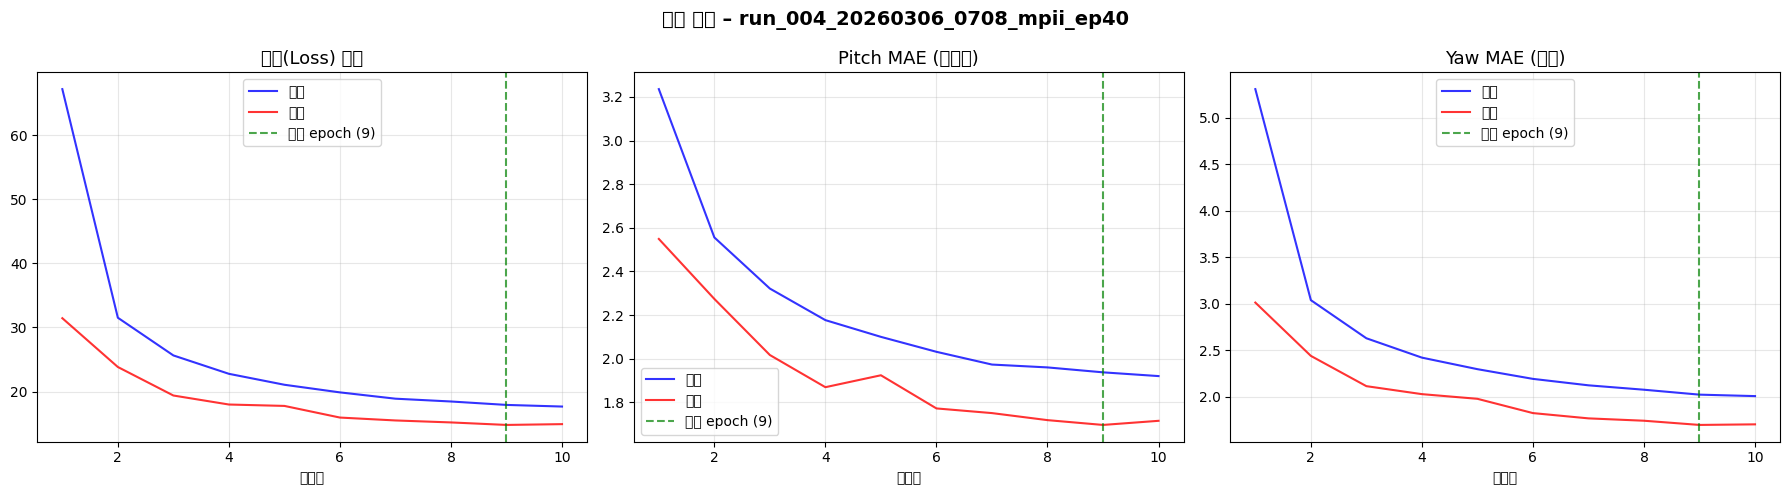

In [15]:
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, tr, val, title in zip(
    axes,
    [history['train_loss'], history['train_mae_p'], history['train_mae_y']],
    [history['val_loss'],   history['val_mae_p'],   history['val_mae_y']],
    ['손실(Loss) 곡선', 'Pitch MAE (위아래)', 'Yaw MAE (좌우)']
):
    ax.plot(epochs_range, tr, 'b-', linewidth=1.5, label='학습', alpha=0.8)
    ax.plot(epochs_range, val,'r-', linewidth=1.5, label='검증', alpha=0.8)
    ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'최고 epoch ({best_epoch})')
    ax.set_title(title, fontsize=13); ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xlabel('에포크')

plt.suptitle(f'학습 결과 – {RUN_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=120, bbox_inches='tight')
with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(SAVE_DIR / 'training_curves.png'), artifact_path='plots')
plt.show()

## 14. 💾 ONNX 내보내기 (브라우저 배포용)

In [16]:
# 최고 모델 불러오기
checkpoint = torch.load(SAVE_DIR / 'best_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval().cpu()

dummy_input = torch.randn(1, 3, 224, 224)
onnx_path   = SAVE_DIR / 'l2csnet_gaze.onnx'

torch.onnx.export(
    model,
    dummy_input,
    str(onnx_path),
    export_params=True,
    opset_version=12,
    do_constant_folding=True,
    input_names=['face_image'],          # JS에서 이 이름으로 입력
    output_names=['pitch_logits', 'yaw_logits', 'pitch_deg', 'yaw_deg'],
    dynamic_axes={'face_image': {0: 'batch_size'}}
)

onnx_size_mb = onnx_path.stat().st_size / 1024 / 1024
print(f"ONNX 내보내기 완료! 파일 크기: {onnx_size_mb:.1f} MB")
print(f"저장 위치: {onnx_path}")

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_artifact(str(onnx_path), artifact_path='onnx')

print(f"\n📂 저장 파일 목록 ({SAVE_DIR.name}):")
for f in sorted(SAVE_DIR.iterdir()):
    print(f"  {f.name:<40} {f.stat().st_size/1024:>8.1f} KB")

print("""
─────────────────────────────────────────────
📌 다음 단계
  MLflow UI:  mlflow ui  →  http://127.0.0.1:5000
  브라우저:   dwell_click_demo.html에서 이 ONNX 파일 선택
─────────────────────────────────────────────
""")

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_120624\44644929.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(SAVE_DIR / 'best_model.pth', map_loca

ONNX 내보내기 완료! 파일 크기: 90.0 MB
저장 위치: checkpoints\run_004_20260306_0708_mpii_ep40\l2csnet_gaze.onnx

📂 저장 파일 목록 (run_004_20260306_0708_mpii_ep40):
  best_model.pth                            92590.9 KB
  l2csnet_gaze.onnx                         92203.8 KB
  mpiigaze_distribution.png                    62.7 KB
  sample_images.png                           331.8 KB
  training_curves.png                          85.3 KB

─────────────────────────────────────────────
📌 다음 단계
  MLflow UI:  mlflow ui  →  http://127.0.0.1:5000
  브라우저:   dwell_click_demo.html에서 이 ONNX 파일 선택
─────────────────────────────────────────────

